In [2]:
from pathlib import Path
import pandas as pd

In [3]:
BULK_DIR = Path.home() / 'project/crc-pm/bulk-data' / 'U-CAN'
clinical_raw = pd.read_excel(
    BULK_DIR / "Supplementary_Table_01.xlsx",
    header=2,
)
# the third row is header, whereas the first two rows are descriptions

In [4]:
COLS = [
    # Sample
    "Sample ID",
    "RNA Tumor Sample Barcode",
    "Peritoneum metastases",

    # Patho
    "Histology Subtype",
    "Primary Site Disease",
    "Tumour Site",
    "Anatomic Organ Subdivision",

    # Molecule
    "MSI Status",
    "CMS Tumour",
    "iCMS Tumour",
    "CRPS Tumour",

    # Treatment
    'Pre-Treated', 
    'Pre-Treated Type',
]
clinical = clinical_raw[COLS]
clinical_pm_assessable = clinical[
    clinical['Peritoneum metastases'].isin(['Yes','No'])
    ]

In [5]:
### preview data using cross table
for column in [
    "Tumour Site", 
    "MSI Status",
    "CMS Tumour",
    "iCMS Tumour",
    "CRPS Tumour",
    'Histology Subtype',]:
    values = clinical_pm_assessable[column].fillna("Missing")
    percentages = pd.crosstab(
        values,
        clinical_pm_assessable["Peritoneum metastases"],
        normalize = 'columns',
    )
    print(f"======Percentage of {column}======")
    print(percentages*100)
    print('\n')

======Percentage of Tumour Site======
Peritoneum metastases         No        Yes
Tumour Site                                
Left Colon             31.111111  33.333333
Rectum                 35.555556  12.500000
Right Colon            33.333333  54.166667


======Percentage of MSI Status======
Peritoneum metastases         No        Yes
MSI Status                                 
MSI                     8.888889  16.666667
MSS                    91.111111  83.333333


======Percentage of CMS Tumour======
Peritoneum metastases         No        Yes
CMS Tumour                                 
CMS1                    5.555556  16.666667
CMS2                   37.777778   4.166667
CMS3                    7.777778  20.833333
CMS4                   31.111111  41.666667
Undefined              17.777778  16.666667


======Percentage of iCMS Tumour======
Peritoneum metastases         No        Yes
iCMS Tumour                                
Undefined               7.777778   8.333333
iCMS2   

In [6]:
# read in data
raw_counts = pd.read_csv(
    BULK_DIR / "CRC.SW.mRNA.count.txt.gz",
    sep="\t",
    index_col=0,
)

tpm_count = pd.read_csv(
    BULK_DIR / "CRC.SW.mRNA.TPM.txt.gz",
    sep="\t",
    index_col=0,
)

print((raw_counts.shape, tpm_count.shape))

((19765, 1183), (19765, 1183))


In [7]:
barcode = clinical_pm_assessable['RNA Tumor Sample Barcode']
raw_counts_pm = raw_counts[barcode].copy()
tpm_count_pm = tpm_count[barcode].copy()

# set index
clinical_pm_assessable = clinical_pm_assessable.set_index(
    "RNA Tumor Sample Barcode",
    drop=False,
)
raw_counts_pm = raw_counts_pm.loc[:, clinical_pm_assessable.index]
tpm_count_pm = tpm_count_pm.loc[:, clinical_pm_assessable.index]

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.04 seconds.

Fitting dispersions...
... done in 1.72 seconds.

Fitting dispersion trend curve...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 2.11 seconds.

Fitting LFCs...
... done in 1.35 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 340 outlier genes.

Fitting dispersions...
... done in 0.07 seconds.

Fitting MAP dispersions...
... done in 0.07 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Running Wald tests...
... done in 0.56 seconds.



Log2 fold change & Wald test p-value: pm Yes vs No
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG.ID                                                                       
ENSG00000121410      6.138200        0.209196  0.330619  0.632741  0.526903   
ENSG00000148584   1794.862373        0.080796  0.263828  0.306245  0.759418   
ENSG00000175899  19409.842936       -0.102383  0.211472 -0.484143  0.628285   
ENSG00000166535     15.433274       -1.033509  0.596929 -1.731376       NaN   
ENSG00000128274    403.259678       -0.291904  0.249923 -1.167973  0.242818   
...                       ...             ...       ...       ...       ...   
ENSG00000203995     12.957483        0.276171  0.442320  0.624369  0.532385   
ENSG00000162378   2155.319362       -0.130447  0.087331 -1.493700  0.135254   
ENSG00000159840   5271.410366        0.016218  0.121186  0.133829  0.893538   
ENSG00000074755   4556.652997        0.035392  0.102045  0.346828  0.728720   
E

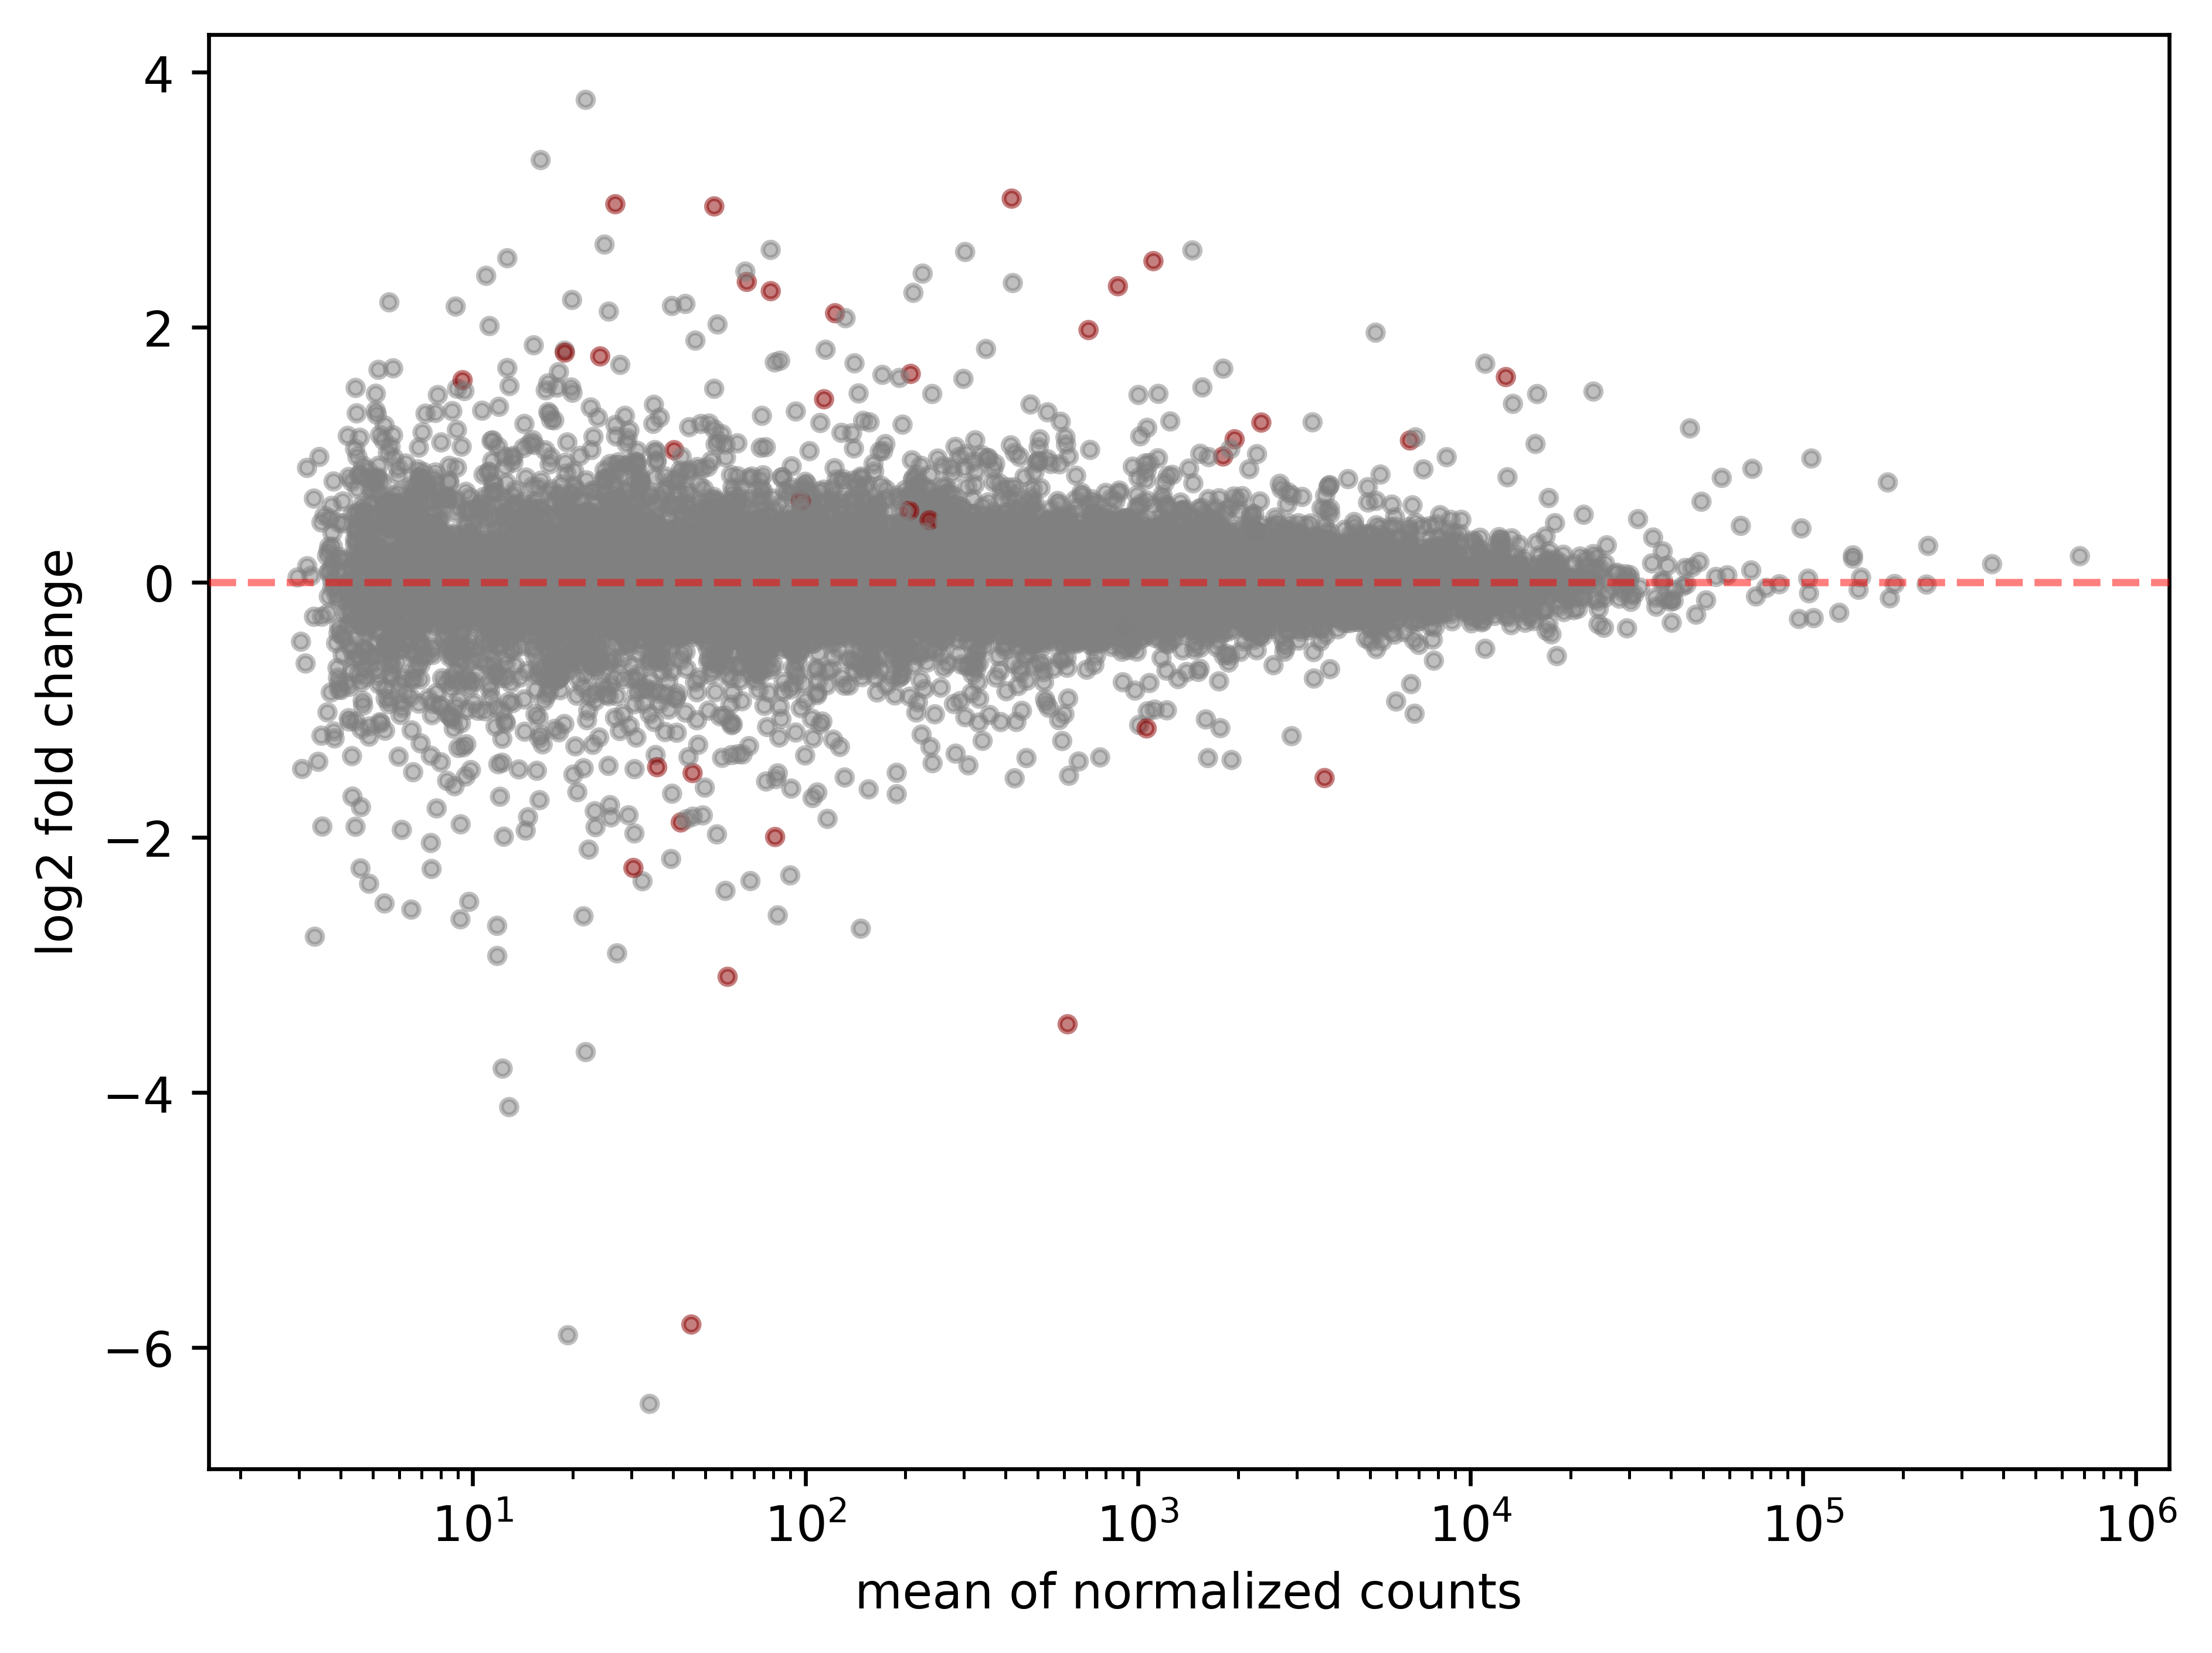

In [22]:
##########
# DEG
##########

### filter gene and transpose
# 在10%的样本中均表达>10的基因 TODO 可以再考虑一下阈值的设置
filtered_gene = (raw_counts_pm >= 10).sum(axis=1) >= raw_counts_pm.shape[1]*0.1
raw_deg = raw_counts_pm[filtered_gene].T

### generate meta data
# formula do not take in ' ' or '-'
metadata = clinical_pm_assessable.copy()
rename_dict = {
    'Tumour Site' : 'site',
    'Pre-Treated' : 'treatment',
    'MSI Status' : 'msi',
    'Histology Subtype' : 'histo',
    'Peritoneum metastases' : 'pm',
}
metadata = metadata.rename(columns = rename_dict)

### DEG
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
design_formulas = {
    'simple' : '~pm',
    'moderate' : "~ site + msi + pm", 
    'full' : "~ site + treatment + msi + histo + pm", 
}
contrast=["pm", "Yes", "No"]
# dds stand for Deseq Data Set
dds = DeseqDataSet(
    counts=raw_deg,
    metadata=metadata,
    design=design_formulas['full'], # a Wilkinson formula that describes the design
    refit_cooks=True, # whether Cooks outlier should be refitted, always recommended
    n_cpus=8,
)
dds.deseq2()
ds = DeseqStats(
    dds,
    contrast=contrast, # ["variable", "tested_level", "control_level"]
    alpha=0.05, # p value threshold 
    n_cpus=8,
)
# PyDESeq2 computes p-values using Wald tests, done by using summary()
# with a threshold of 0.1()
ds.summary()
de_table = ds.results_df.copy()
ds.plot_MA(s=10)

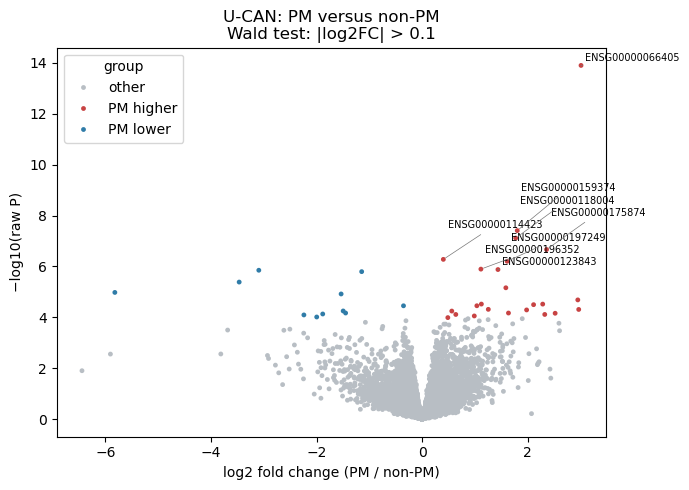

In [ ]:
### TODO 整理这个函数

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def volcano(
    results,
    effect="log2FoldChange",
    label="log2 fold change (PM / non-PM)",
    significance="padj",
    title="U-CAN: PM versus non-PM",
    save_prefix=None,
):
    d = results.copy()
    d["minus_log10_p"] = -np.log10(d["pvalue"].clip(lower=1e-300))

    d["group"] = "other"
    d.loc[
        (d[significance] < 0.05) & (d[effect] > 0),
        "group",
    ] = "PM higher"
    d.loc[
        (d[significance] < 0.05) & (d[effect] < 0),
        "group",
    ] = "PM lower"

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(
        data=d,
        x=effect,
        y="minus_log10_p",
        hue="group",
        hue_order=["other", "PM higher", "PM lower"],
        palette={
            "other": "#b8bec4",
            "PM higher": "#c84343",
            "PM lower": "#307ca8",
        },
        s=12,
        linewidth=0,
        ax=ax,
    )

    labels = (
        d.dropna(subset=["pvalue", effect])
        .nsmallest(8, "pvalue")
        .sort_values("minus_log10_p")
    )

    last_y = -np.inf
    gap = max(0.15, float(d["minus_log10_p"].max()) * 0.035)

    for gene_id, row in labels.iterrows():
        # 有 symbol 时使用 symbol，否则使用 Ensembl ID
        symbol = row.get("symbol")
        gene_label = (
            str(symbol)
            if pd.notna(symbol) and str(symbol).strip()
            else str(gene_id)
        )

        text_y = max(row["minus_log10_p"] + gap / 3, last_y + gap)
        ax.annotate(
            gene_label,
            (row[effect], row["minus_log10_p"]),
            fontsize=7,
            xytext=(row[effect] + 0.08, text_y),
            textcoords="data",
            arrowprops={
                "arrowstyle": "-",
                "color": "#777777",
                "lw": 0.5,
            },
        )
        last_y = text_y

    ax.set(
        xlabel=label,
        ylabel="−log10(raw P)",
        title=title,
    )

    # 只有按 raw p 判断显著性时才画这条阈值线
    if significance == "pvalue":
        ax.axhline(
            -np.log10(0.05),
            linestyle="--",
            linewidth=0.8,
            color="#777777",
        )

    fig.tight_layout()

    if save_prefix is not None:
        fig.savefig(f"{save_prefix}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_prefix}.png", dpi=300, bbox_inches="tight")

    return fig, ax

fig, ax = volcano(
    de_before_shrink,
    title="U-CAN: PM versus non-PM\nWald test: |log2FC| > 0.1",
)
plt.show()